In [38]:
import pandas as pd
import numpy as np
from IPython.display import display
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/test.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25976 entries, 0 to 25975
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         25976 non-null  int64  
 1   id                                 25976 non-null  int64  
 2   Gender                             25976 non-null  object 
 3   Customer Type                      25976 non-null  object 
 4   Age                                25976 non-null  int64  
 5   Type of Travel                     25976 non-null  object 
 6   Class                              25976 non-null  object 
 7   Flight Distance                    25976 non-null  int64  
 8   Inflight wifi service              25976 non-null  int64  
 9   Departure/Arrival time convenient  25976 non-null  int64  
 10  Ease of Online booking             25976 non-null  int64  
 11  Gate location                      25976 non-null  int

In [39]:
df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied


In [40]:
df.drop(columns=["Unnamed: 0", "id"], inplace=True)

In [41]:
df.isna().sum()

Gender                                0
Customer Type                         0
Age                                   0
Type of Travel                        0
Class                                 0
Flight Distance                       0
Inflight wifi service                 0
Departure/Arrival time convenient     0
Ease of Online booking                0
Gate location                         0
Food and drink                        0
Online boarding                       0
Seat comfort                          0
Inflight entertainment                0
On-board service                      0
Leg room service                      0
Baggage handling                      0
Checkin service                       0
Inflight service                      0
Cleanliness                           0
Departure Delay in Minutes            0
Arrival Delay in Minutes             83
satisfaction                          0
dtype: int64

In [42]:
df.dropna(inplace=True)

In [43]:
df.duplicated().sum()

0

In [44]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,25893.0,39.621983,15.134224,7.0,27.0,40.0,51.0,85.0
Flight Distance,25893.0,1193.753254,998.626779,31.0,414.0,849.0,1744.0,4983.0
Inflight wifi service,25893.0,2.723709,1.334711,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,25893.0,3.046422,1.532971,0.0,2.0,3.0,4.0,5.0
Ease of Online booking,25893.0,2.755996,1.412552,0.0,2.0,3.0,4.0,5.0
Gate location,25893.0,2.976442,1.281661,1.0,2.0,3.0,4.0,5.0
Food and drink,25893.0,3.214923,1.331895,0.0,2.0,3.0,4.0,5.0
Online boarding,25893.0,3.261615,1.355505,0.0,2.0,4.0,4.0,5.0
Seat comfort,25893.0,3.448886,1.320254,1.0,2.0,4.0,5.0,5.0
Inflight entertainment,25893.0,3.356969,1.338643,0.0,2.0,4.0,4.0,5.0


In [45]:
df.describe(include="object").T

,count,unique,top,freq
Gender,25893,2,Female,13127
Customer Type,25893,2,Loyal Customer,21111
Type of Travel,25893,2,Business travel,17980
Class,25893,3,Business,12457
satisfaction,25893,2,neutral or dissatisfied,14528


In [46]:
num_cols = df.select_dtypes("number").columns
cat_cols = df.select_dtypes("object").columns

print(f"Num cols: {num_cols}")
print(f"Cat cols: {cat_cols}")

Num cols: Index(['Age', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes',
       'Arrival Delay in Minutes'],
      dtype='object')
Cat cols: Index(['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction'], dtype='object')


### See Outliers

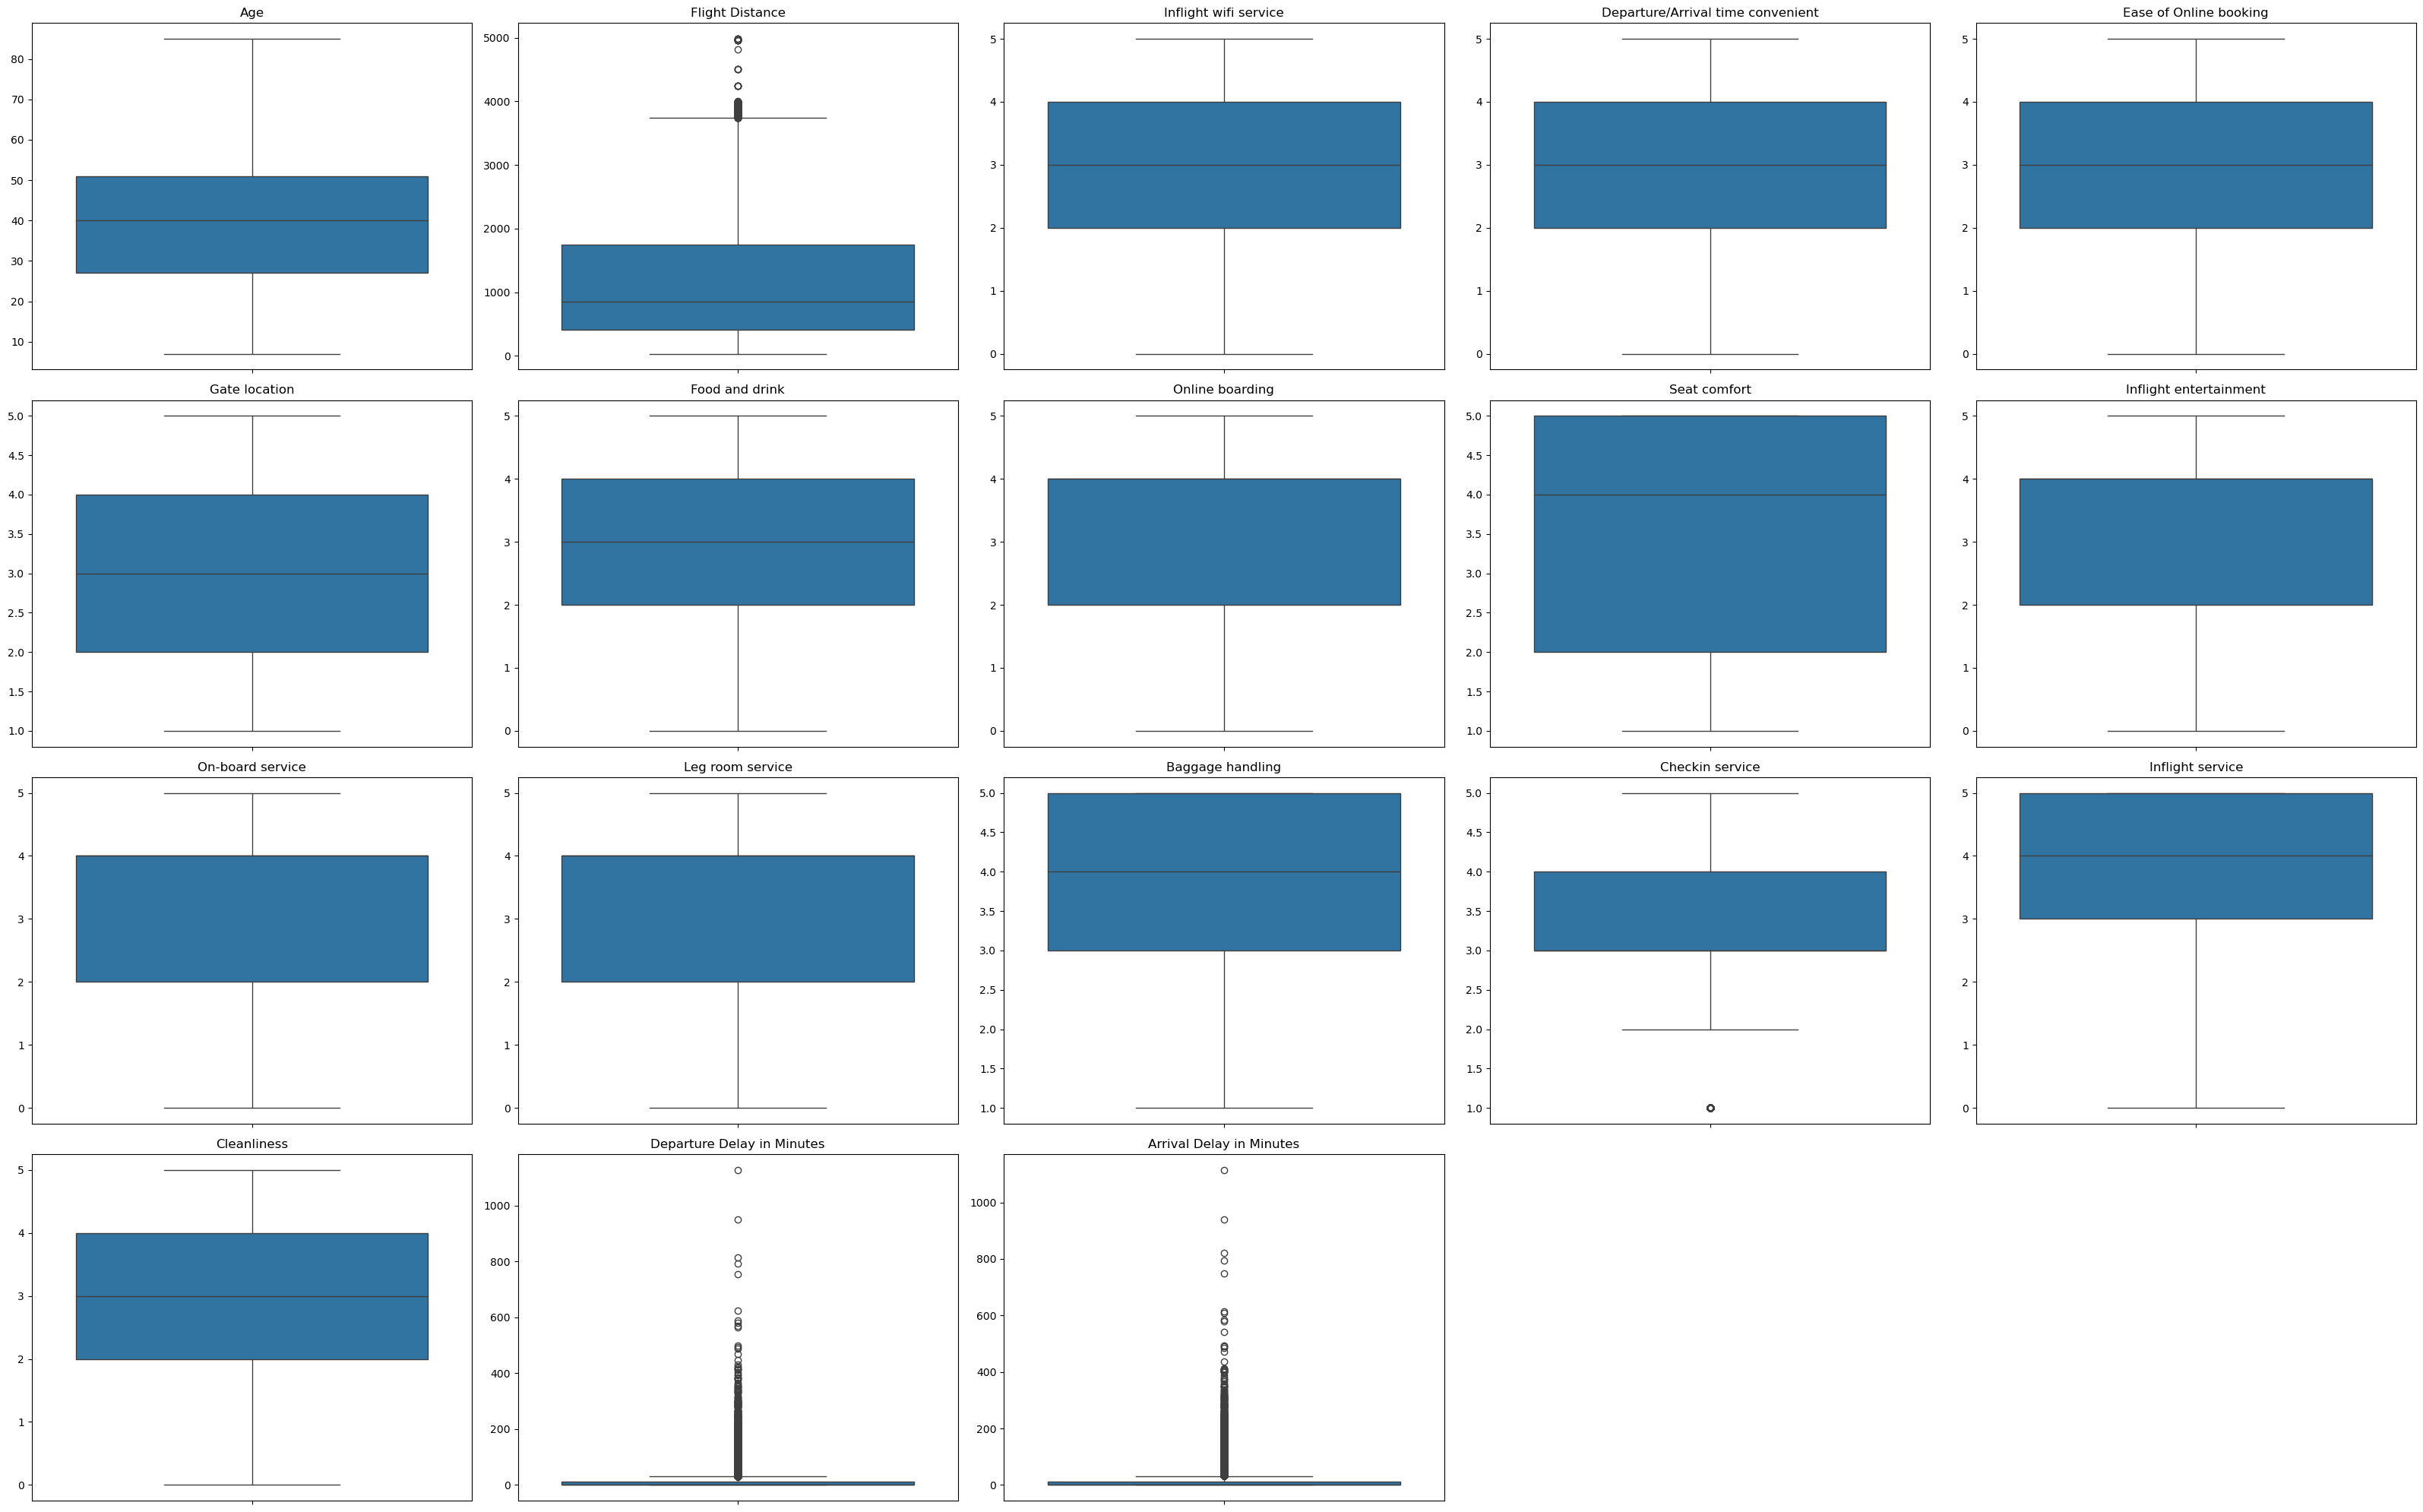

In [47]:
n_cols = 5
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_rows*8, n_cols*4))
ax = ax.flatten()

for i, col in enumerate(num_cols):
    ax[i].set_title(col)
    
    sns.boxplot(
        ax=ax[i],
        y=df[col]
    )
    
    ax[i].set_ylabel(None)
    
for j in range(len(num_cols), n_cols*n_rows):
    fig.delaxes(ax[j])

plt.tight_layout()
plt.show()

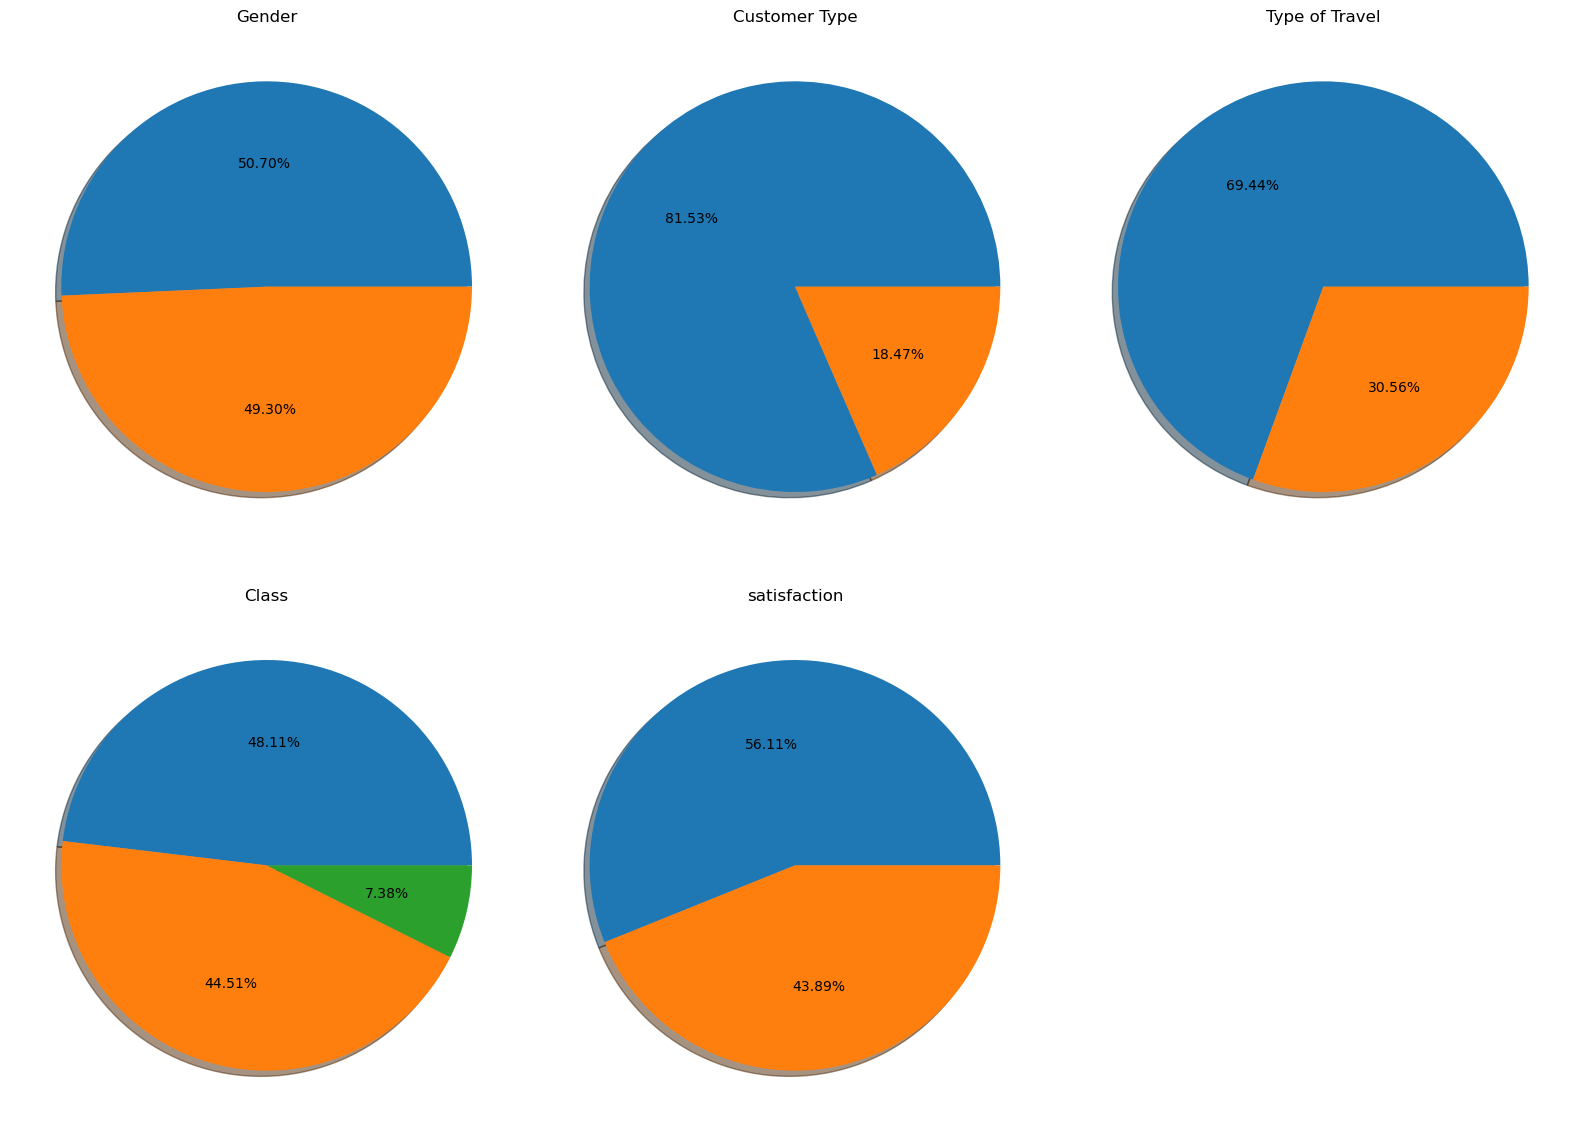

In [48]:
n_cols = 3
n_rows = int(np.ceil(len(cat_cols) / n_cols))

fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_rows*8, n_cols*4))
ax = ax.flatten()

for i, col in enumerate(cat_cols):
    data = df[col].value_counts()
    
    ax[i].set_title(col)
    
    ax[i].pie(
        data,
        autopct="%.2f%%",
        shadow=True
    )
    
for j in range(len(cat_cols), n_cols*n_rows):
    fig.delaxes(ax[j])

plt.tight_layout()
plt.show()

### Encoding

In [49]:
def label_encoder(df: pd.DataFrame):
    struct = dict()
    
    for col in df.select_dtypes("object").columns:
        unq = df[col].unique()
        unq_map = {v: k for k, v in enumerate(unq)}
        
        struct[col] = unq_map
        df[col] = df[col].map(unq_map)
    
    return df, struct


df_enc, struct = label_encoder(df)

display(struct)
df_enc.head()

{'Gender': {'Female': 0, 'Male': 1},
 'Customer Type': {'Loyal Customer': 0, 'disloyal Customer': 1},
 'Type of Travel': {'Business travel': 0, 'Personal Travel': 1},
 'Class': {'Eco': 0, 'Business': 1, 'Eco Plus': 2},
 'satisfaction': {'satisfied': 0, 'neutral or dissatisfied': 1}}

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,0,52,0,0,160,5,4,3,4,...,5,5,5,5,2,5,5,50,44.0,0
1,0,0,36,0,1,2863,1,1,3,1,...,4,4,4,4,3,4,5,0,0.0,0
2,1,1,20,0,0,192,2,0,2,4,...,2,4,1,3,2,2,2,0,0.0,1
3,1,0,44,0,1,3377,0,0,0,2,...,1,1,1,1,3,1,4,0,6.0,0
4,0,0,49,0,0,1182,2,3,4,3,...,2,2,2,2,4,2,4,0,20.0,0


### Splitting data

In [50]:
def train_test_split(
    X: pd.DataFrame, y: pd.DataFrame, test_size: float = 0.2, random_state=None
):
    if random_state:
        np.random.seed(random_state)
    
    n_samples = len(X)
    shuffle_indices = np.random.permutation(np.arange(n_samples))
    
    test_size = round(test_size * n_samples)
    train_size = test_size - n_samples
    
    train_size = shuffle_indices[:train_size]
    test_size = shuffle_indices[test_size:]
    
    X_train, X_test = X.iloc[train_size], X.iloc[test_size]
    y_train, y_test = y.iloc[train_size], y.iloc[test_size]
    
    return [X_train, X_test, y_train, y_test]


X = df_enc.drop(columns=["satisfaction"])
y = df_enc.satisfaction

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
X_train.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
19461,0,1,25,0,0,846,3,4,4,3,...,3,3,4,1,4,3,4,3,51,59.0
11180,0,0,52,1,2,2425,1,4,1,1,...,5,1,1,1,1,5,1,5,0,0.0
13968,0,0,65,1,1,1120,4,2,4,3,...,4,4,4,4,1,1,4,4,94,90.0
5202,0,0,41,1,0,1172,3,5,3,2,...,1,1,4,4,3,4,4,1,0,6.0
13988,0,0,67,1,0,731,2,1,2,2,...,3,2,2,2,2,2,2,2,0,0.0


### Scaler

#### Min-Max Scaler

In [51]:
def min_max_scaler(X: pd.DataFrame):
    return ((X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0)))

X_train_mm_scaler = min_max_scaler(X_train)
X_test_mm_scaler = min_max_scaler(X_test)

X_train_mm_scaler.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
19461,0.0,1.0,0.230769,0.0,0.0,0.164580,0.6,0.8,0.8,0.50,...,0.50,0.6,0.8,0.2,0.75,0.50,0.8,0.50,0.064232,0.074214
11180,0.0,0.0,0.576923,1.0,1.0,0.483441,0.2,0.8,0.2,0.00,...,1.00,0.2,0.2,0.2,0.00,1.00,0.2,1.00,0.000000,0.000000
13968,0.0,0.0,0.743590,1.0,0.5,0.219911,0.8,0.4,0.8,0.50,...,0.75,0.8,0.8,0.8,0.00,0.00,0.8,0.75,0.118388,0.113208
5202,0.0,0.0,0.435897,1.0,0.0,0.230412,0.6,1.0,0.6,0.25,...,0.00,0.2,0.8,0.8,0.50,0.75,0.8,0.00,0.000000,0.007547
13988,0.0,0.0,0.769231,1.0,0.0,0.141357,0.4,0.2,0.4,0.25,...,0.50,0.4,0.4,0.4,0.25,0.25,0.4,0.25,0.000000,0.000000


#### Standard Scaler

In [52]:
def std_scaler(X: pd.DataFrame):
    return ((X - X.mean(axis=0)) / X.std(axis=0))

X_train_std_scaler = std_scaler(X_train)
X_test_std_scaler = std_scaler(X_test)

X_train_std_scaler.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
19461,-0.990105,2.12752,-0.954997,-0.675214,-1.020535,-0.352539,0.197310,0.609622,0.877051,0.011052,...,-0.347080,-0.260425,0.483727,-1.785630,0.315522,-0.248570,0.290342,-0.220950,0.988967,1.181055
11180,-0.990105,-0.46994,0.835013,1.480726,2.203223,1.212765,-1.299935,0.609622,-1.250465,-1.557157,...,1.167263,-1.745008,-1.865653,-1.785630,-2.206221,1.329057,-2.225578,1.283718,-0.381887,-0.388451
13968,-0.990105,-0.46994,1.696870,1.480726,0.591344,-0.080916,0.945933,-0.707538,0.877051,0.011052,...,0.410092,0.481866,0.483727,0.480797,-2.206221,-1.826197,0.290342,0.531384,2.144784,2.005710
5202,-0.990105,-0.46994,0.105750,1.480726,-1.020535,-0.029367,0.197310,1.268201,0.167879,-0.773053,...,-1.861423,-1.745008,0.483727,0.480797,-0.525059,0.540244,0.290342,-1.725618,-0.381887,-0.228840
13988,-0.990105,-0.46994,1.829463,1.480726,-1.020535,-0.466542,-0.551312,-1.366117,-0.541293,-0.773053,...,-0.347080,-1.002717,-1.082527,-1.030155,-1.365640,-1.037383,-1.386938,-0.973284,-0.381887,-0.388451


#### Principal Components Analysis (PCA)

##### Explain Variance Ratio

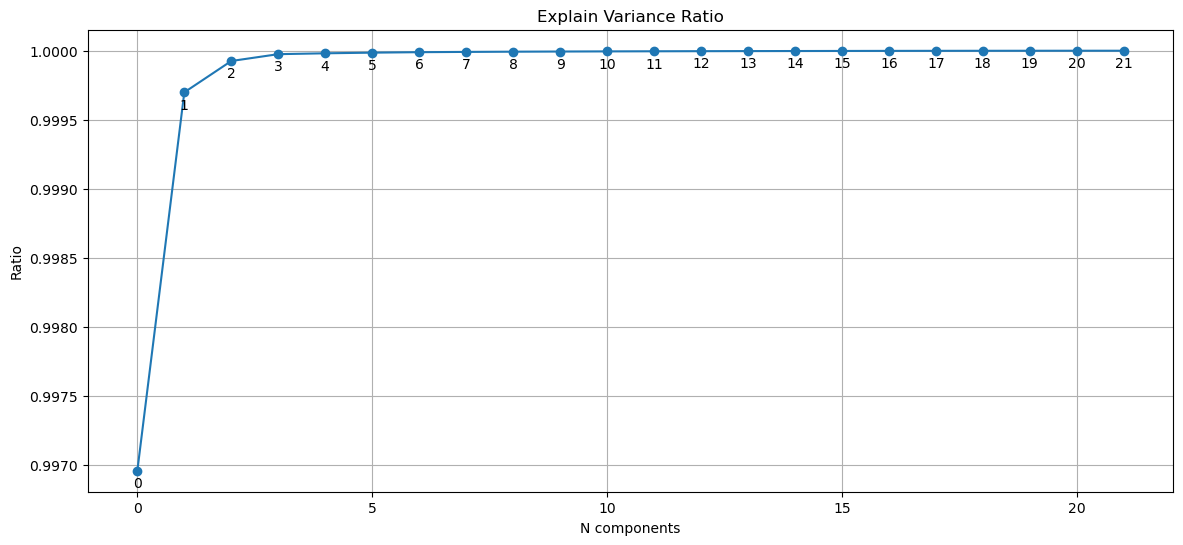

In [53]:
def explain_variance_ratio(X: pd.DataFrame):
    x_centered = X - X.mean()
    cov_matrix = np.cov(x_centered, rowvar=False)
    eigenvalues, _ = np.linalg.eigh(cov_matrix)
    sorted_eigenvalues = np.sort(eigenvalues)[::-1]
    total = sorted_eigenvalues.sum()
    
    return sorted_eigenvalues / total

evr = explain_variance_ratio(X)
cumsum = np.cumsum(evr)

plt.figure(figsize=(14, 6))
plt.title("Explain Variance Ratio")
plt.plot(cumsum, marker="o")
plt.xlabel("N components")
plt.ylabel("Ratio")
plt.grid(True)

for i, y in enumerate(cumsum):
    plt.annotate(str(i), (i, y), ha="center", textcoords="offset points", xytext=(0, -12))

plt.show()

In [54]:
threshold = 0.95
n_components = np.argmax(cumsum >= threshold) + 1
print(f"Jumlah n_components yang di perlukan untuk menjelaskan {threshold*100}% adalah {n_components}")

Jumlah n_components yang di perlukan untuk menjelaskan 95.0% adalah 1


#### Build PCA

In [63]:
def pca(X: pd.DataFrame, n_components: int):
    x_center = X - X.mean()
    cov_matrix = np.cov(x_center, rowvar=False)

    eigenvalues, eigenmatrix = np.linalg.eigh(cov_matrix)

    sorted_indices = np.argsort(eigenvalues)[::-1]
    sorted_eigenmatrix = eigenmatrix[:, sorted_indices]

    principal_components = sorted_eigenmatrix[:, :n_components]
    
    X_pca = np.dot(x_center, principal_components)
    return pd.DataFrame(X_pca)


X_train_pca = pca(X_train, n_components=1)
X_test_pca = pca(X_test, n_components=1)

X_train_pca.head(10)

,0
0,-355.659504
1,1223.397864
2,-81.605689
3,-29.620134
4,-470.576979
5,-864.600013
6,-660.634750
7,2308.352861
8,1502.300074
9,-905.602374


### Build KNN model

In [56]:
class KNN:
    def __init__(self, k: int, p: int, weight):
        self.k = k
        self.p = p
        self.weight = weight

    def _minkowski_distance(self, a, b):
        return np.power(np.sum(np.abs(a - b) ** self.p, axis=0), 1 / self.p)

    def _get_nn(self, X_test: pd.DataFrame):
        
        distances = self._minkowski_distance(X_test, self.X_train)  # Hitung semua jarak test dengan train
        k_idxs = np.argsort(distances)[: self.k]                    # Urutkan jarak dan dapatkan index yang mendekati k
        
        k_labels = [self.y_train[i] for i in k_idxs]                # Dapatkan index label dengan jarak yg sudah di urutkan
        
        k_distance = [distances[i] for i in k_idxs]                 # Dapatkan index distance kembali namun yang sudah di urutkan

        if self.weight == "uniform":
            values, counts = np.unique(k_labels, return_counts=True)
            # proses vooting candidates, pilih acak jika jumlah sama
            max_count = max(counts)
            candidates = values[counts == max_count]
            return np.random.choice(candidates)

        elif self.weight == "distance":
            weights = [(1 / (d + 1e-5)) for d in k_distance]

        elif callable(self.weight):
            weights = [self.weight(d) for d in k_distance]

        # proses vooting candidates, pilih acak jika jumlah sama
        label_weight = dict()
        for label, weight in zip(k_labels, weights):
            label_weight[label] = label_weight.get(label, 0) + weight

        max_weight = max(label_weight.values())
        candidates = [
            label for label, weight in label_weight.items() if weight == max_weight
        ]
        return np.random.choice(candidates)

    def fit(self, X_train: pd.DataFrame, y_train: pd.DataFrame):
        self.X_train = X_train.to_numpy()
        self.y_train = y_train.to_numpy()

    def predict(self, X_test: pd.DataFrame):
        return np.array([self._get_nn(x) for x in X_test.to_numpy()])

### Evaluation Model

In [57]:
class EvaluationModel:
    def __init__(self, y_true: pd.DataFrame, y_pred: np.ndarray):
        self.y_true = y_true
        self.y_pred = y_pred

    def accuracy(self):
        return np.sum(self.y_true == self.y_pred) / len(self.y_true)

    def precision(self, TP, FP):
        return TP / (TP + FP) if (TP + FP) != 0 else 0

    def recall(self, TP, FN):
        return TP / (TP + FN) if (TP + FN) != 0 else 0

    def f1_score(self, TP, FP, FN):
        P = self.precision(TP, FP)
        R = self.recall(TP, FN)

        return 2 * (P * R) / (P + R) if (P + R) != 0 else 0

    def macro_avg(self, result_df: pd.DataFrame):
        return result_df[["Precision", "Recall", "F1-Score"]].mean()

    def weighted_avg(self, result_df: pd.DataFrame):
        class_counts = pd.Series(self.y_true).value_counts()
        total_samples = len(self.y_true)

        weighted_score = dict()
        for col in ["Precision", "Recall", "F1-Score"]:
            weighted_sum = 0
            for i, row in result_df.iterrows():
                if row["Category"] not in ["macro avg", "weighted_avg"]:
                    cat = row["Category"]
                    cat_weight = class_counts.get(cat, 0) / total_samples
                    weighted_sum += cat_weight * row[col]
                
            weighted_score[col] = weighted_sum
        
        return weighted_score

    def make_report(self):
        cats = pd.Series(self.y_true).unique()
        reports = {"Category": [], "Precision": [], "Recall": [], "F1-Score": []}

        for cat in cats:
            # Confusion Matrix
            TP = np.sum(
                (self.y_true == cat) & (self.y_pred == cat)
            )  # Asli POSITIF prediksi POSITIF
            TN = np.sum(
                (self.y_true != cat) & (self.y_pred != cat)
            )  # Asli NEGATIF prediksi NEGATIF
            FP = np.sum(
                (self.y_true != cat) & (self.y_pred == cat)
            )  # Asli NEGATIF prediksi POSITIF
            FN = np.sum(
                (self.y_true == cat) & (self.y_pred != cat)
            )  # Asli POSITIF prediksi NEGATIF

            # Calculation Matrix
            P = self.precision(TP, FP)
            R = self.recall(TP, FN)
            F1 = self.f1_score(TP, FP, FN)

            # Append Matrix
            reports["Category"].append(cat)
            reports["Precision"].append(P)
            reports["Recall"].append(R)
            reports["F1-Score"].append(F1)

        accuracy = self.accuracy()

        reports_df = pd.DataFrame(reports)

        macro_avg = self.macro_avg(reports_df)
        weighted_avg = self.weighted_avg(reports_df)

        summary_df = pd.DataFrame.from_records(
            [
                {"Category": "macro avg", **macro_avg},
                {"Category": "weighted avg", **weighted_avg},
            ]
        )

        results_df = pd.concat([reports_df, summary_df], ignore_index=True)

        return results_df, accuracy

### Implementasi manual

#### Try 1

In [58]:
model_1 = KNN(k=3, p=1, weight="uniform")
model_1.fit(X_train_mm_scaler, y_train)

preds = model_1.predict(X_test_mm_scaler)

# evaluation
eval_model_1 = EvaluationModel(y_test, preds)
report_model_1, accuracy_model_1 = eval_model_1.make_report()

print(f"Accuracy model 1: {accuracy_model_1}")
report_model_1

Accuracy model 1: 0.5623249975861736


,Category,Precision,Recall,F1-Score
0,0,0.333333,0.000110,0.000221
1,1,0.562358,0.999828,0.719839
2,macro avg,0.447846,0.499969,0.360030
3,weighted avg,0.462131,0.562325,0.404915


#### Try 2

In [59]:
model_2 = KNN(k=5, p=2, weight="uniform")
model_2.fit(X_train_std_scaler, y_train)

preds = model_2.predict(X_test_std_scaler)

# evaluation
eval_model_2 = EvaluationModel(y_test, preds)
report_model_2, accuracy_model_2 = eval_model_2.make_report()

print(f"Accuracy model 2: {accuracy_model_2}")
report_model_2

Accuracy model 2: 0.47871005117311966


,Category,Precision,Recall,F1-Score
0,0,0.266001,0.108660,0.154292
1,1,0.525013,0.766675,0.623238
2,macro avg,0.395507,0.437667,0.388765
3,weighted avg,0.411662,0.478710,0.418015


#### Try 3

In [60]:
model_3 = KNN(k=8, p=3, weight="distance")
model_3.fit(X_train_std_scaler, y_train)

preds = model_3.predict(X_test_std_scaler)

# evaluation
eval_model_3 = EvaluationModel(y_test, preds)
report_model_3, accuracy_model_3 = eval_model_3.make_report()

print(f"Accuracy model 3: {accuracy_model_3}")
report_model_3

Accuracy model 3: 0.462585690837115


,Category,Precision,Recall,F1-Score
0,0,0.277885,0.142637,0.188511
1,1,0.516095,0.711563,0.598268
2,macro avg,0.396990,0.427100,0.393390
3,weighted avg,0.411848,0.462586,0.418947


### Grid Search CV Hypertunning parameter

In [61]:
def logging_training_model(params_result: dict, index: int, total: int):
    seprator = "=" * 100
    text_process = f"[{index}/{total}] [{index/total*100:.2f}%]"

    print(seprator)
    print(text_process)
    print(params_result)
    print(seprator)


def hypertunning_parameter(params: dict, limit_data: int = None):
    total_loop = (
        len(params["K"])
        * len(params["P"])
        * len(params["weight"])
        * len(params["scaler"])
    )

    count = 1

    param_list = list()

    for k in params["K"]:
        for p in params["P"]:
            for weight in params["weight"]:
                for i, (train, test) in enumerate(params["scaler"]):
                    # Initialization KNN model
                    model = KNN(k=k, p=p, weight=weight)
                    model.fit(X_train=train[:limit_data], y_train=y_train[:limit_data])

                    preds = model.predict(X_test=test[:limit_data])

                    # Evaluation KNN model
                    eval_model = EvaluationModel(
                        y_true=y_test[:limit_data], y_pred=preds
                    )
                    report_df, accuracy = eval_model.make_report()

                    # Append params
                    params_results = {
                        "K": k,
                        "P": p,
                        "weight": weight,
                        "scaler": i,
                    }

                    param_list.append(
                        {
                            "accuracy": accuracy,
                            "result_df": report_df,
                            "params": params_results,
                        }
                    )

                    # Logging
                    logging_training_model(
                        params_result=params_results, index=count, total=total_loop
                    )

                    count += 1
    return param_list

In [ ]:
def custom_distance(d):
    return 1 / (d**2 + 1e-5)


params = {
    "K": range(3, 10),
    "P": range(1, 4),
    "weight": ["uniform", "distance", custom_distance],
    "scaler": [
        (X_train_mm_scaler, X_test_mm_scaler),
        (X_train_std_scaler, X_test_std_scaler),
        (X_train_pca, X_test_pca),
        (X_train, X_test),
    ],
}

param_results = hypertunning_parameter(params)

# Sorting and show
sorted_best_params = sorted(param_results, key=lambda x: x["accuracy"], reverse=True)[:5]

for param in sorted_best_params:
    print(f"Params: {param["params"]}")
    display(param["result_df"])
    print(f"Accuracy: {param["accuracy"]}\n")

[1/252] [0.40%]
{'K': 3, 'P': 1, 'weight': 'uniform', 'scaler': 0}
[2/252] [0.79%]
{'K': 3, 'P': 1, 'weight': 'uniform', 'scaler': 1}
[3/252] [1.19%]
{'K': 3, 'P': 1, 'weight': 'uniform', 'scaler': 2}
[4/252] [1.59%]
{'K': 3, 'P': 1, 'weight': 'uniform', 'scaler': 3}
[5/252] [1.98%]
{'K': 3, 'P': 1, 'weight': 'distance', 'scaler': 0}
[6/252] [2.38%]
{'K': 3, 'P': 1, 'weight': 'distance', 'scaler': 1}
[7/252] [2.78%]
{'K': 3, 'P': 1, 'weight': 'distance', 'scaler': 2}
[8/252] [3.17%]
{'K': 3, 'P': 1, 'weight': 'distance', 'scaler': 3}
[9/252] [3.57%]
{'K': 3, 'P': 1, 'weight': <function custom_distance at 0x0000027C3908DA80>, 'scaler': 0}
[10/252] [3.97%]
{'K': 3, 'P': 1, 'weight': <function custom_distance at 0x0000027C3908DA80>, 'scaler': 1}
[11/252] [4.37%]
{'K': 3, 'P': 1, 'weight': <function custom_distance at 0x0000027C3908DA80>, 'scaler': 2}
[12/252] [4.76%]
{'K': 3, 'P': 1, 'weight': <function custom_distance at 0x0000027C3908DA80>, 'scaler': 3}
[13/252] [5.16%]
{'K': 3, 'P': 2,

,Category,Precision,Recall,F1-Score
0,0,1.000000,0.041667,0.080000
1,1,0.530612,1.000000,0.693333
2,macro avg,0.765306,0.520833,0.386667
3,weighted avg,0.755918,0.540000,0.398933


Accuracy: 0.54

Params: {'K': 4, 'P': 3, 'weight': 'uniform', 'scaler': 0}


,Category,Precision,Recall,F1-Score
0,0,1.000000,0.020833,0.040816
1,1,0.525253,1.000000,0.688742
2,macro avg,0.762626,0.510417,0.364779
3,weighted avg,0.753131,0.530000,0.377738


Accuracy: 0.53

Params: {'K': 8, 'P': 2, 'weight': 'uniform', 'scaler': 0}


...

Accuracy: 0.53

Params: {'K': 8, 'P': 3, 'weight': 'uniform', 'scaler': 0}


,Category,Precision,Recall,F1-Score
0,0,1.000000,0.020833,0.040816
1,1,0.525253,1.000000,0.688742
2,macro avg,0.762626,0.510417,0.364779
3,weighted avg,0.753131,0.530000,0.377738


Accuracy: 0.53

Params: {'K': 9, 'P': 2, 'weight': 'uniform', 'scaler': 0}


,Category,Precision,Recall,F1-Score
0,0,1.000000,0.020833,0.040816
1,1,0.525253,1.000000,0.688742
2,macro avg,0.762626,0.510417,0.364779
3,weighted avg,0.753131,0.530000,0.377738


Accuracy: 0.53

